In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv")

# quick check
print(df.head())
print(df.info())

   user_id              name                   email_address  \
0        1     Ronald Murphy      williamholland@example.com   
1        2       Scott Allen             scott22@example.org   
2        3  Jonathan Parrish            brooke16@example.org   
3        4    Megan Williams         elizabeth31@example.net   
4        5     Kathryn Brown  pattersonalexandra@example.org   

             username date_of_birth  gender        location  \
0      williamholland    1953-06-03    Male  Rebeccachester   
1             scott22    1978-07-08    Male   Mcphersonview   
2            brooke16    1994-12-06  Female       Youngfort   
3         elizabeth31    1964-12-22  Female    Feliciashire   
4  pattersonalexandra    1961-06-04    Male    Port Deborah   

  membership_start_date membership_end_date subscription_plan  \
0            2024-01-15          2025-01-14            Annual   
1            2024-01-07          2025-01-06           Monthly   
2            2024-04-13          2025-04-


Missing Values:
 user_id                          0
name                             0
email_address                    0
username                         0
date_of_birth                    0
gender                           0
location                         0
membership_start_date            0
membership_end_date              0
subscription_plan                0
payment_information              0
renewal_status                   0
usage_frequency                  0
purchase_history                 0
favorite_genres                  0
devices_used                     0
engagement_metrics               0
feedback_ratings                 0
customer_support_interactions    0
dtype: int64


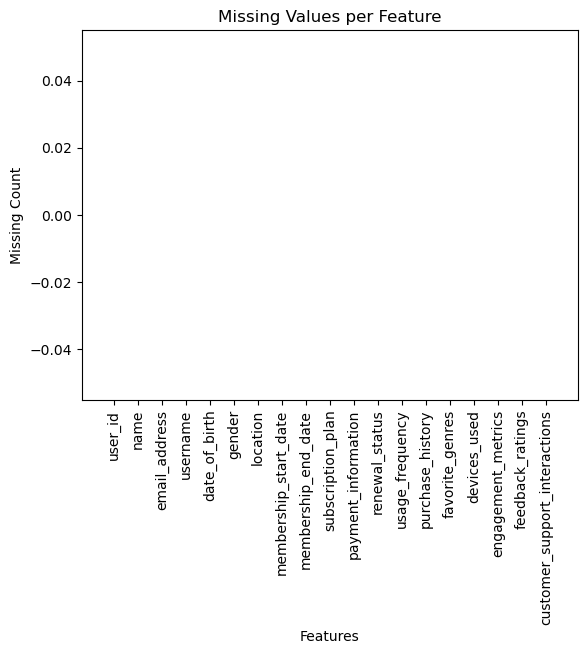

In [72]:
missing = df.isnull().sum()
print("\nMissing Values:\n", missing)

plt.figure()

plt.bar(missing.index, missing.values)

plt.xticks(rotation=90)
plt.title("Missing Values per Feature")
plt.xlabel("Features")
plt.ylabel("Missing Count")

plt.show()

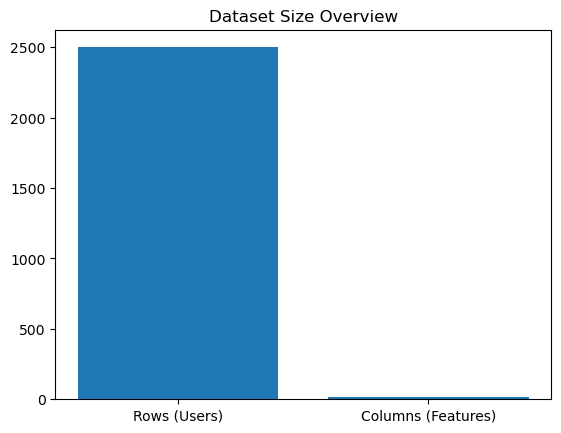

In [73]:
plt.figure()

sizes = [df.shape[0], df.shape[1]]
labels = ["Rows (Users)", "Columns (Features)"]

plt.bar(labels, sizes)

plt.title("Dataset Size Overview")

plt.show()

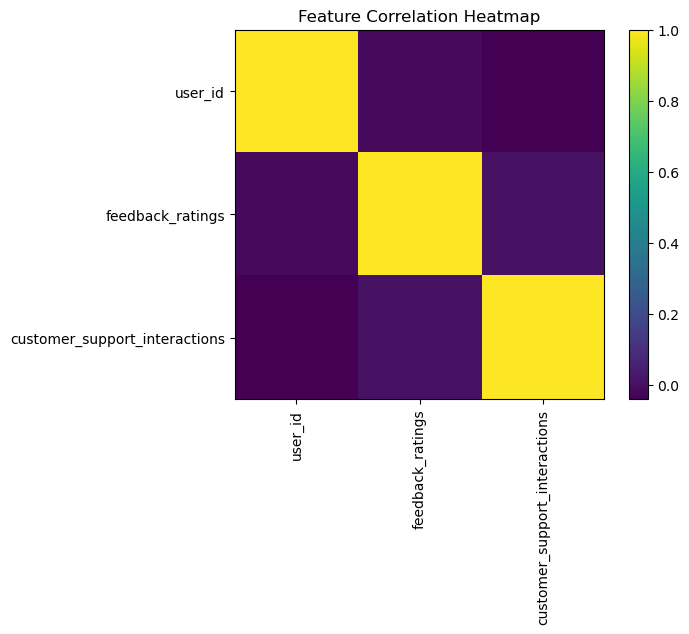

In [74]:
numeric_df = df.select_dtypes(include=['int64','float64'])

corr = numeric_df.corr()

plt.figure()

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Feature Correlation Heatmap")

plt.show()

In [75]:
columns_df = pd.DataFrame({
    "Feature Names":df.columns
})

print(columns_df)

                    Feature Names
0                         user_id
1                            name
2                   email_address
3                        username
4                   date_of_birth
5                          gender
6                        location
7           membership_start_date
8             membership_end_date
9               subscription_plan
10            payment_information
11                 renewal_status
12                usage_frequency
13               purchase_history
14                favorite_genres
15                   devices_used
16             engagement_metrics
17               feedback_ratings
18  customer_support_interactions


In [76]:
df_encoded = df.copy()

for col in df_encoded.columns:
    
    if df_encoded[col].dtype == 'object':
        
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

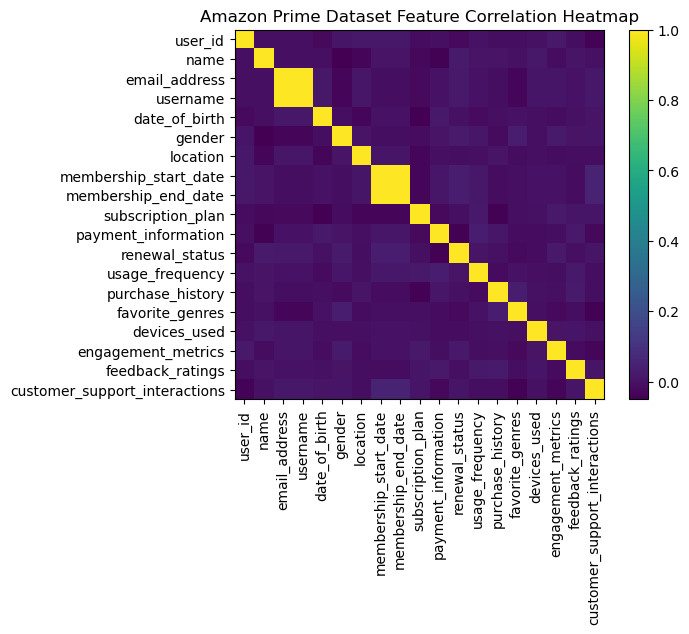

In [77]:
corr_matrix = df_encoded.corr()

plt.figure()

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Amazon Prime Dataset Feature Correlation Heatmap")

plt.show()

```mermaid
flowchart TB

A[Amazon Prime Dataset]

A --> B[Rows: 2500]
A --> C[Columns: 19]

C --> D[user_id]
C --> E[name]
C --> F[email_address]
C --> G[username]
C --> H[date_of_birth]
C --> I[gender]
C --> J[location]
C --> K[membership_start_date]
C --> L[membership_end_date]
C --> M[subscription_plan]
C --> N[payment_information]
C --> O[renewal_status]
C --> P[usage_frequency]
C --> Q[purchase_history]
C --> R[favorite_genres]
C --> S[devices_used]
C --> T[engagement_metrics]
C --> U[feedback_ratings]
C --> V[customer_support_interactions]

```mermaid
flowchart TB

A[Amazon Prime Dataset]

A --> B[Rows: 2500]
A --> C[Columns: 19]

C --> D[user_id]
C --> E[name]
C --> F[email_address]
C --> G[username]
C --> H[date_of_birth]
C --> I[gender]
C --> J[location]
C --> K[membership_start_date]
C --> L[membership_end_date]
C --> M[subscription_plan]
C --> N[payment_information]
C --> O[renewal_status]
C --> P[usage_frequency]
C --> Q[purchase_history]
C --> R[favorite_genres]
C --> S[devices_used]
C --> T[engagement_metrics]
C --> U[feedback_ratings]
C --> V[customer_support_interactions]

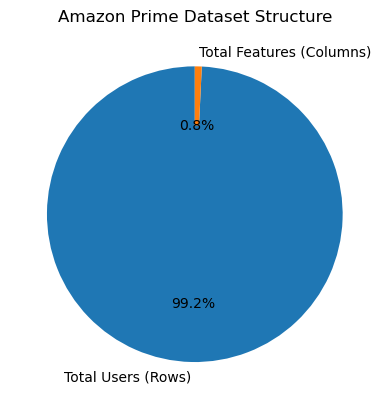

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

rows = df.shape[0]
cols = df.shape[1]

sizes = [rows, cols]
labels = ['Total Users (Rows)', 'Total Features (Columns)']

plt.figure()

wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

# donut hole
centre_circle = plt.Circle((0,0),0.60)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Amazon Prime Dataset Structure")

plt.show()

In [79]:
summary = pd.DataFrame({
    "Metric": ["Total Users (Rows)", "Total Features (Columns)"],
    "Value": [df.shape[0], df.shape[1]]
})

print(summary)

                     Metric  Value
0        Total Users (Rows)   2500
1  Total Features (Columns)     19


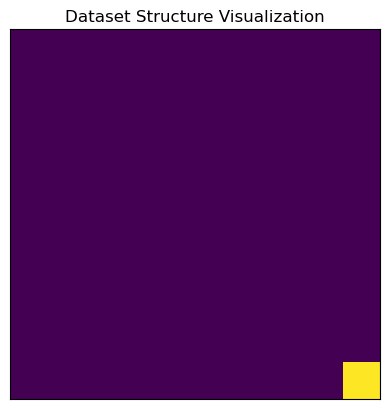

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

rows, cols = df.shape

data = [rows, cols]
labels = ["Rows (Users)", "Columns (Features)"]

total = sum(data)

# create waffle grid
grid_size = 100
proportions = [int((value/total)*grid_size) for value in data]

waffle = np.zeros(grid_size)

waffle[:proportions[0]] = 1
waffle[proportions[0]:] = 2

waffle = waffle.reshape(10,10)

plt.figure()

plt.imshow(waffle)

plt.title("Dataset Structure Visualization")

plt.xticks([])
plt.yticks([])

plt.show()

In [81]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


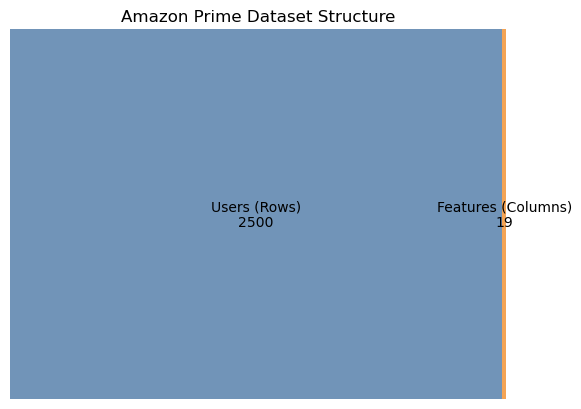

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import squarify

# Load dataset
path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

# dataset shape
rows, cols = df.shape

sizes = [rows, cols]

labels = [
    f"Users (Rows)\n{rows}",
    f"Features (Columns)\n{cols}"
]

colors = ["#4E79A7", "#F28E2B"]

plt.figure()

squarify.plot(
    sizes=sizes,
    label=labels,
    color=colors,
    alpha=0.8
)

plt.title("Amazon Prime Dataset Structure")

plt.axis("off")

plt.show()

ValueError: number of labels (22) does not match number of bars (21).

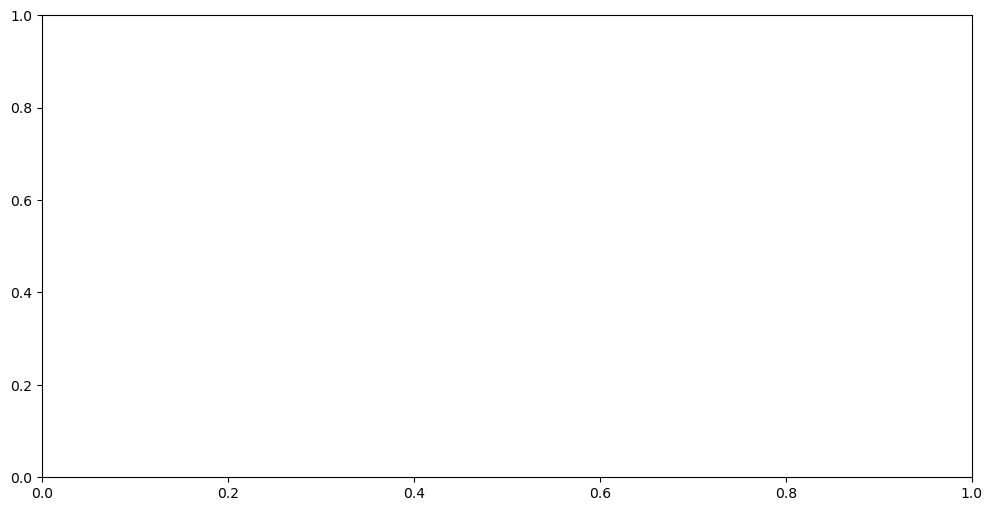

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import squarify

# load dataset
path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

rows, cols = df.shape

# hierarchy sizes
sizes = [rows, cols] + [1]*len(df.columns)

labels = ["Dataset (Total Records)",
          f"Rows: {rows}",
          f"Columns: {cols}"] + list(df.columns)

colors = ["#2E86AB", "#F6C85F"] + ["#6F4E7C"]*len(df.columns)

plt.figure(figsize=(12,6))

squarify.plot(
    sizes=sizes,
    label=labels,
    color=colors,
    alpha=0.85
)

plt.axis("off")
plt.title("Amazon Prime Dataset Structure and Features")

plt.show()

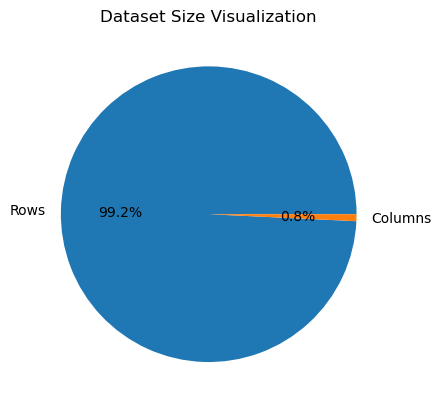

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

rows, cols = df.shape

labels = ["Rows", "Columns"]
values = [rows, cols]

plt.figure()

plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title("Dataset Size Visualization")

plt.show()

In [ ]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


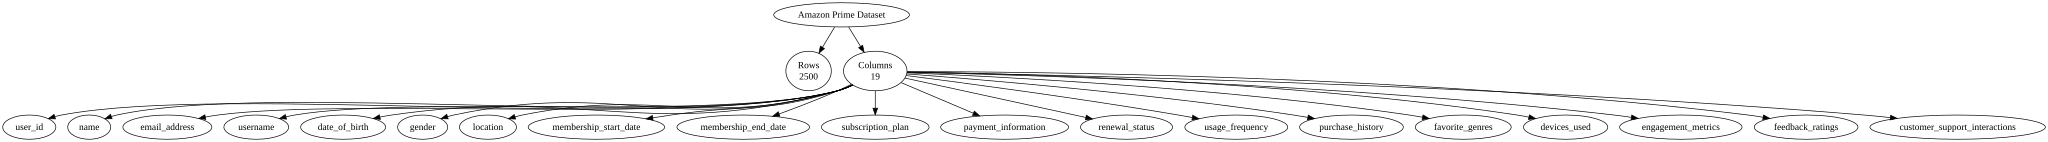

In [ ]:
import pandas as pd
from graphviz import Digraph

# load dataset
path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

rows, cols = df.shape

dot = Digraph()

# top node
dot.node('A', 'Amazon Prime Dataset')

# second level
dot.node('B', f'Rows\n{rows}')
dot.node('C', f'Columns\n{cols}')

dot.edge('A','B')
dot.edge('A','C')

# add column names
for i,col in enumerate(df.columns):
    
    node_id = f'col{i}'
    
    dot.node(node_id, col)
    
    dot.edge('C', node_id)

dot

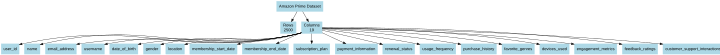

In [ ]:
import pandas as pd
from graphviz import Digraph

# load dataset
path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

rows, cols = df.shape

dot = Digraph(comment="Dataset Structure")

# graph size
dot.attr(size='10,80')

# square style nodes
dot.attr('node', shape='box', style='filled', color='lightblue', fontname="Arial")

# top node
dot.node('A', 'Amazon Prime Dataset')

# second level
dot.node('B', f'Rows\n{rows}')
dot.node('C', f'Columns\n{cols}')

dot.edge('A','B')
dot.edge('A','C')

# column nodes
for i, col in enumerate(df.columns):
    
    node_id = f'col{i}'
    
    dot.node(node_id, col)
    
    dot.edge('C', node_id)

dot

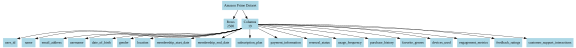

In [ ]:
import pandas as pd
from graphviz import Digraph

# load dataset
path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

rows, cols = df.shape

dot = Digraph(comment="Dataset Structure")

# vertical layout
dot.attr(rankdir='TB', size='8,100')

# node style
dot.attr('node', shape='box', style='filled', color='lightblue')

# top node
dot.node('A', 'Amazon Prime Dataset')

# second level
dot.node('B', f'Rows\n{rows}')
dot.node('C', f'Columns\n{cols}')

dot.edge('A','B')
dot.edge('A','C')

# column nodes
for i, col in enumerate(df.columns):
    
    node_id = f'col{i}'
    
    dot.node(node_id, col)
    
    dot.edge('C', node_id)

dot

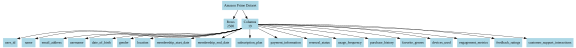

In [ ]:
import pandas as pd
from graphviz import Digraph

# load dataset
path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

rows, cols = df.shape

dot = Digraph(comment="Dataset Structure")

# vertical layout
dot.attr(rankdir='TB', size='8,10')

# node style
dot.attr('node', shape='box', style='filled', color='lightblue')

# top node
dot.node('A', 'Amazon Prime Dataset')

# second level
dot.node('B', f'Rows\n{rows}')
dot.node('C', f'Columns\n{cols}')

dot.edge('A','B')
dot.edge('A','C')

# column nodes
for i, col in enumerate(df.columns):
    
    node_id = f'col{i}'
    
    dot.node(node_id, col)
    
    dot.edge('C', node_id)

dot

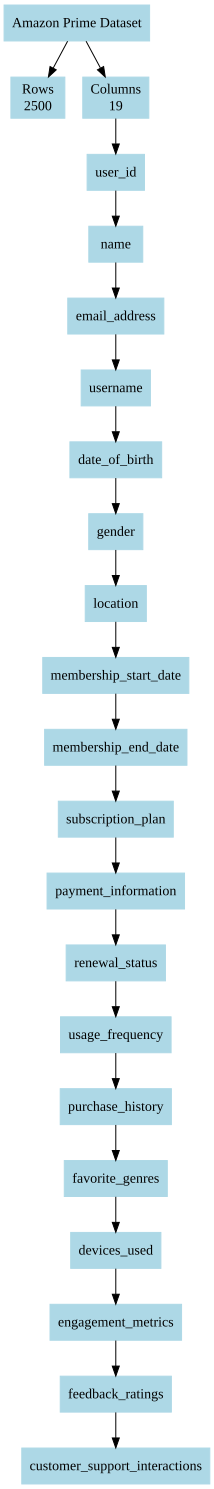

In [ ]:
import pandas as pd
from graphviz import Digraph

# load dataset
path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

rows, cols = df.shape

dot = Digraph()

# vertical direction
dot.attr(rankdir='TB')

# node style
dot.attr('node', shape='box', style='filled', color='lightblue')

# top nodes
dot.node('A', 'Amazon Prime Dataset')
dot.node('B', f'Rows\n{rows}')
dot.node('C', f'Columns\n{cols}')

dot.edge('A','B')
dot.edge('A','C')

# make columns vertical
previous = 'C'

for i, col in enumerate(df.columns):

    node_id = f'col{i}'
    
    dot.node(node_id, col)
    
    dot.edge(previous, node_id)
    
    previous = node_id

dot

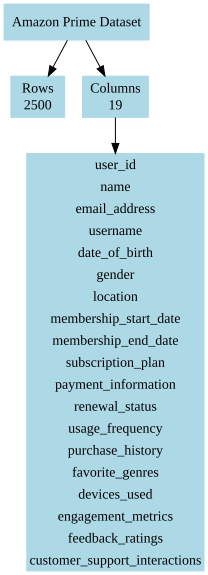

In [ ]:
import pandas as pd
from graphviz import Digraph

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

rows, cols = df.shape

dot = Digraph()
dot.attr(rankdir='TB')

dot.attr('node', shape='box', style='filled', color='lightblue')

# top nodes
dot.node('A', 'Amazon Prime Dataset')
dot.node('B', f'Rows\n{rows}')
dot.node('C', f'Columns\n{cols}')

dot.edge('A','B')
dot.edge('A','C')

# create vertical column list
column_table = "<<TABLE BORDER='0' CELLBORDER='1' CELLSPACING='0'>"

for col in df.columns:
    column_table += f"<TR><TD>{col}</TD></TR>"

column_table += "</TABLE>>"

dot.node('D', column_table, shape='plain')

dot.edge('C','D')

dot

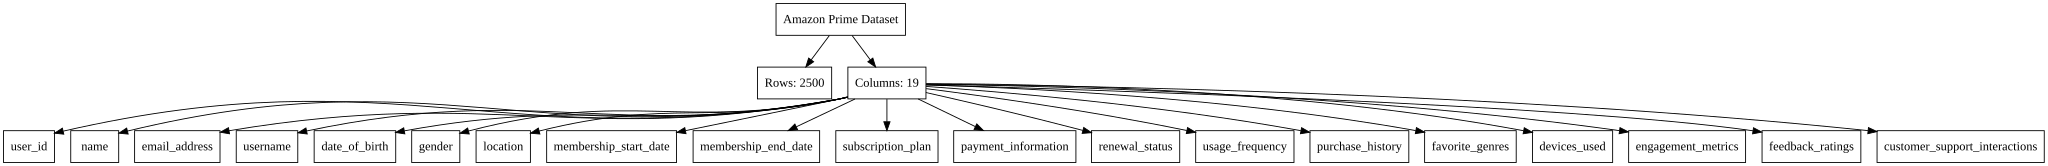

In [ ]:
from graphviz import Digraph

dot = Digraph()

dot.attr(rankdir='TB')
dot.attr('node', shape='box')

dot.node('A', 'Amazon Prime Dataset')

dot.node('B', 'Rows: 2500')
dot.node('C', 'Columns: 19')

dot.edge('A','B')
dot.edge('A','C')

columns = [
"user_id",
"name",
"email_address",
"username",
"date_of_birth",
"gender",
"location",
"membership_start_date",
"membership_end_date",
"subscription_plan",
"payment_information",
"renewal_status",
"usage_frequency",
"purchase_history",
"favorite_genres",
"devices_used",
"engagement_metrics",
"feedback_ratings",
"customer_support_interactions"
]

for i,col in enumerate(columns):
    
    node = f'C{i}'
    
    dot.node(node, col)
    
    dot.edge('C', node)

dot

In [ ]:
columns = [
"user_id",
"name",
"email_address",
"username",
"date_of_birth",
"gender",
"location",
"membership_start_date",
"membership_end_date",
"subscription_plan",
"payment_information",
"renewal_status",
"usage_frequency",
"purchase_history",
"favorite_genres",
"devices_used",
"engagement_metrics",
"feedback_ratings",
"customer_support_interactions"
]

print("Amazon Prime Dataset")
print("        |")
print("   -------------")
print("   |           |")
print(" Rows(2500)       Columns(19)")
print("                |")
print("        ------------------")

for col in columns:
    print("        " + col)

Amazon Prime Dataset
        |
   -------------
   |           |
 Rows(2500)       Columns(19)
                |
        ------------------
        user_id
        name
        email_address
        username
        date_of_birth
        gender
        location
        membership_start_date
        membership_end_date
        subscription_plan
        payment_information
        renewal_status
        usage_frequency
        purchase_history
        favorite_genres
        devices_used
        engagement_metrics
        feedback_ratings
        customer_support_interactions


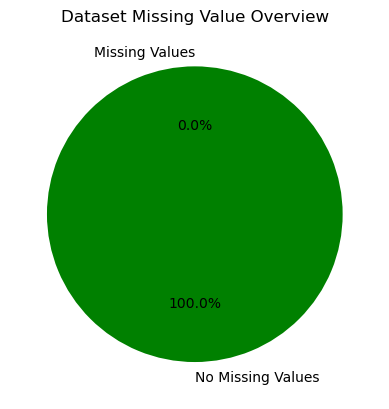

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# load dataset
path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

# count missing and non-missing values
missing = df.isnull().sum().sum()
non_missing = df.size - missing

values = [non_missing, missing]
labels = ['No Missing Values', 'Missing Values']
colors = ['green', 'red']

plt.figure()

plt.pie(values,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Dataset Missing Value Overview")

plt.show()

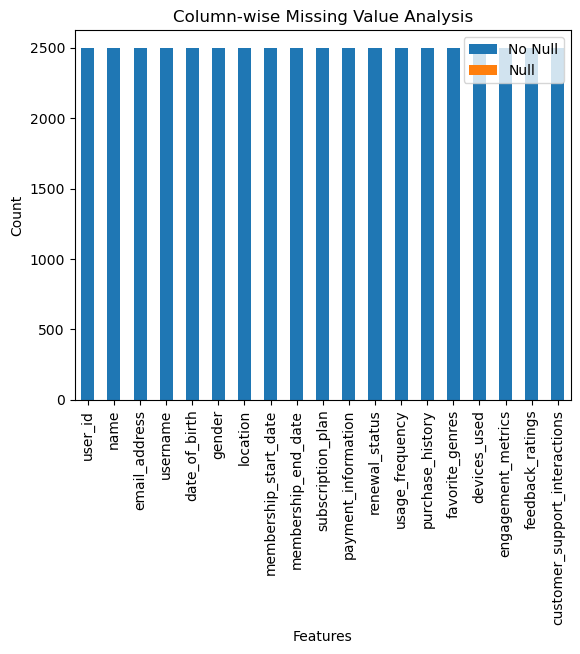

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

# count missing and non-missing
missing = df.isnull().sum()
not_missing = df.notnull().sum()

missing_df = pd.DataFrame({
    "No Null": not_missing,
    "Null": missing
})

missing_df.plot(kind="bar", stacked=True)

plt.title("Column-wise Missing Value Analysis")
plt.xlabel("Features")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

In [ ]:
null_table = pd.DataFrame({
    "Total Rows": df.shape[0],
    "No Null Values": df.notnull().sum(),
    "Null Values": df.isnull().sum()
})

print(null_table)

                               Total Rows  No Null Values  Null Values
user_id                              2500            2500            0
name                                 2500            2500            0
email_address                        2500            2500            0
username                             2500            2500            0
date_of_birth                        2500            2500            0
gender                               2500            2500            0
location                             2500            2500            0
membership_start_date                2500            2500            0
membership_end_date                  2500            2500            0
subscription_plan                    2500            2500            0
payment_information                  2500            2500            0
renewal_status                       2500            2500            0
usage_frequency                      2500            2500            0
purcha

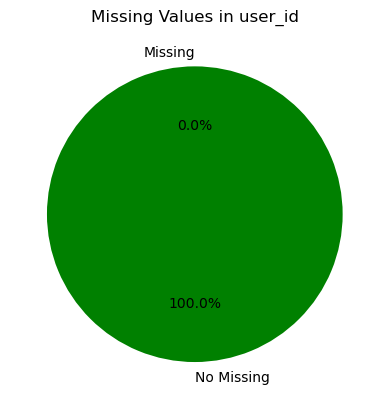

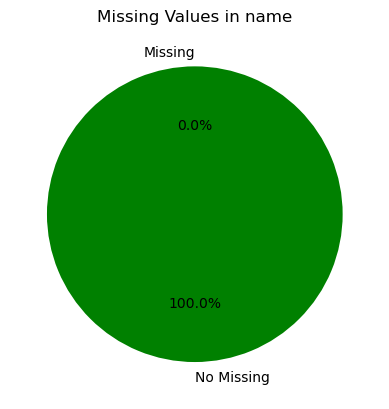

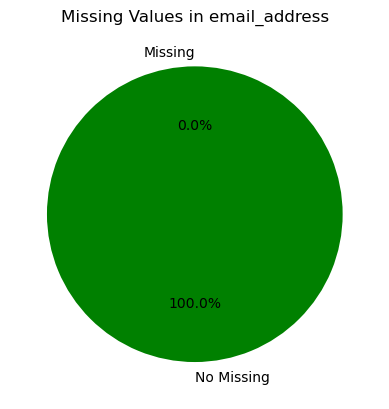

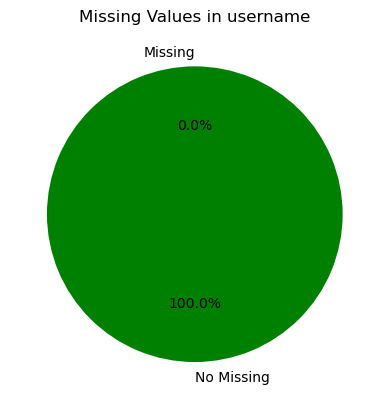

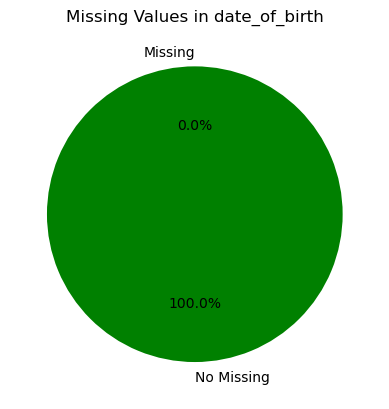

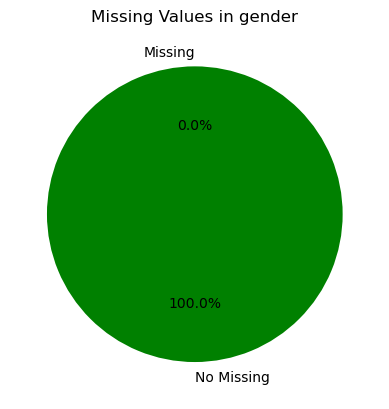

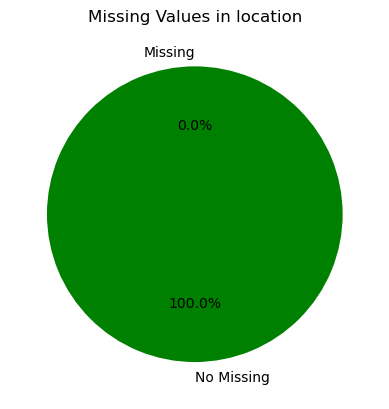

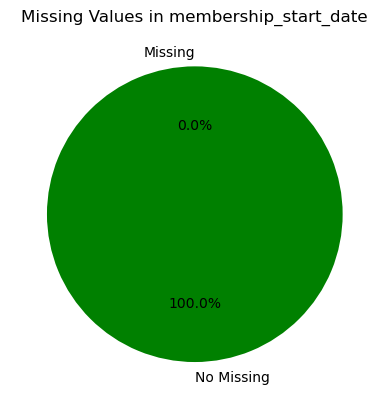

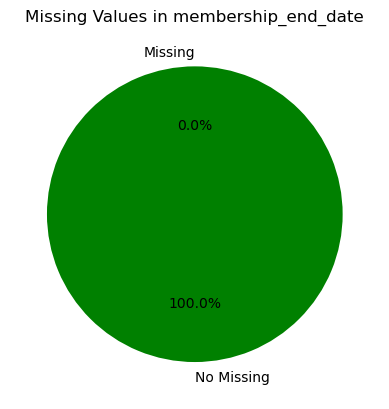

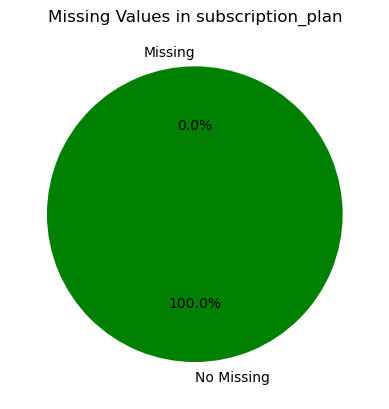

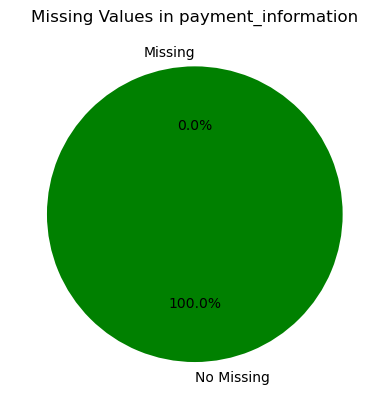

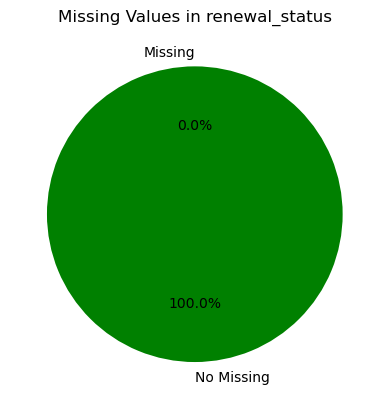

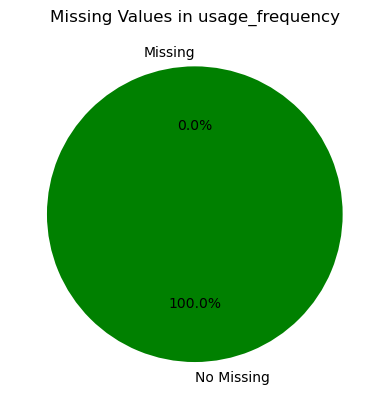

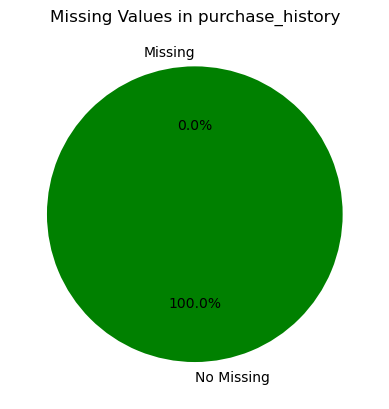

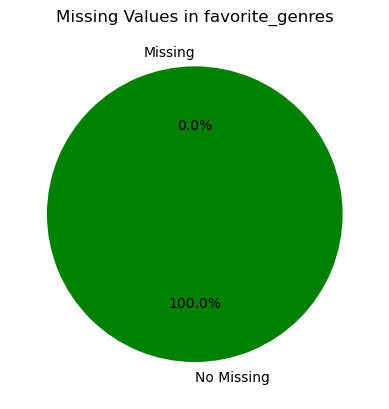

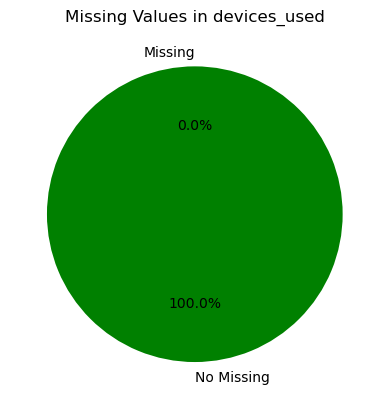

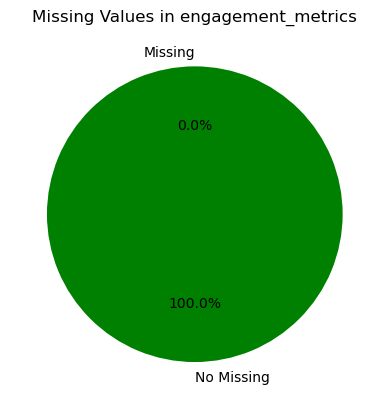

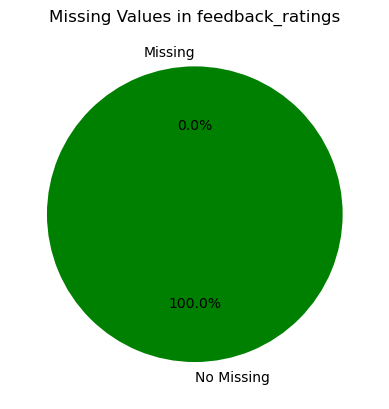

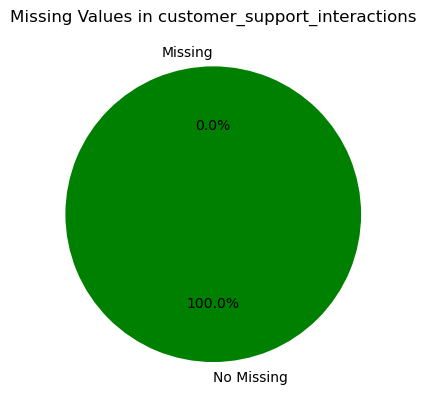

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# load dataset
path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

for col in df.columns:
    
    missing = df[col].isnull().sum()
    not_missing = df.shape[0] - missing
    
    values = [not_missing, missing]
    labels = ['No Missing', 'Missing']
    colors = ['green','red']
    
    plt.figure()
    
    plt.pie(values,
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            startangle=90)
    
    plt.title(f"Missing Values in {col}")
    
    plt.show()

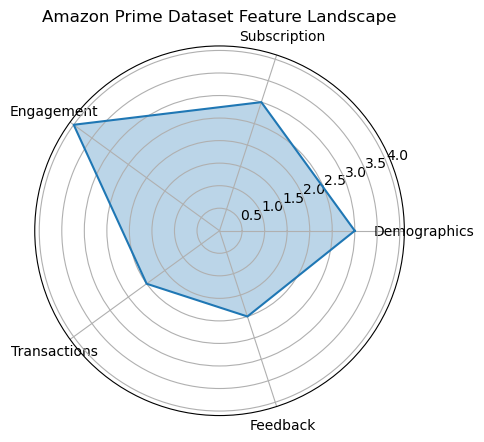

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# dataset path
path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

categories = [
    "Demographics",
    "Subscription",
    "Engagement",
    "Transactions",
    "Feedback"
]

values = [3,3,4,2,2]   # number of features in each group

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False)

values = np.concatenate((values,[values[0]]))
angles = np.concatenate((angles,[angles[0]]))

plt.figure()

ax = plt.subplot(111, polar=True)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.3)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.title("Amazon Prime Dataset Feature Landscape")

plt.show()

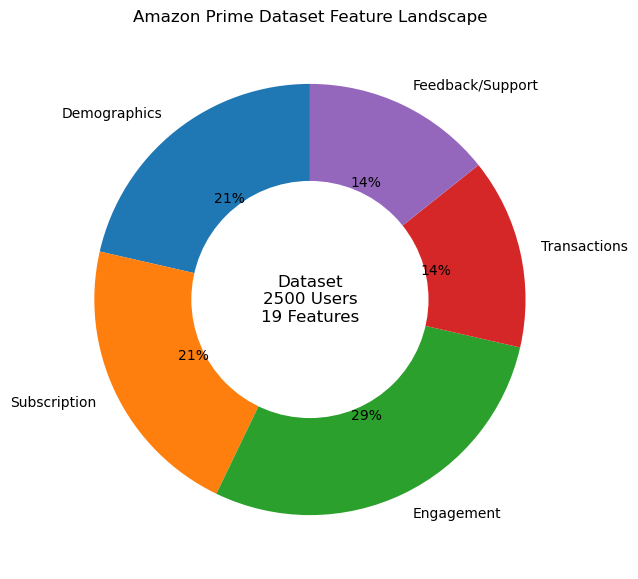

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

rows, cols = df.shape

feature_groups = {
"Demographics":3,
"Subscription":3,
"Engagement":4,
"Transactions":2,
"Feedback/Support":2
}

labels = list(feature_groups.keys())
sizes = list(feature_groups.values())

plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.0f%%',
    startangle=90
)

# donut hole
centre = plt.Circle((0,0),0.55,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre)

plt.text(0,0,f"Dataset\n{rows} Users\n{cols} Features",
         ha='center',va='center',fontsize=12)

plt.title("Amazon Prime Dataset Feature Landscape")

plt.show()

In [ ]:
pip install plotly

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

rows, cols = df.shape
missing = df.isnull().sum().sum()

fig = make_subplots(
    rows=1, cols=3,
    specs=[[{"type":"indicator"},{"type":"pie"},{"type":"bar"}]],
    subplot_titles=("Dataset Size","Missing Values","Feature Groups")
)

# dataset size indicator
fig.add_trace(
    go.Indicator(
        mode="number+delta",
        value=rows,
        title={"text":"Total Users"},
        delta={"reference":0}
    ),
    row=1, col=1
)

# missing value pie
fig.add_trace(
    go.Pie(
        labels=["Valid Values","Missing Values"],
        values=[df.size-missing, missing],
        marker=dict(colors=["green","red"])
    ),
    row=1, col=2
)

# feature groups
feature_groups = {
"Demographics":3,
"Subscription":3,
"Engagement":4,
"Transactions":2,
"Feedback":2
}

fig.add_trace(
    go.Bar(
        x=list(feature_groups.keys()),
        y=list(feature_groups.values())
    ),
    row=1, col=3
)

fig.update_layout(
    title="Amazon Prime Dataset Overview",
    height=500
)

fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

data = dict(
    feature=[
        "gender","location","date_of_birth",
        "membership_start_date","membership_end_date","subscription_plan","renewal_status",
        "usage_frequency","favorite_genres","devices_used","engagement_metrics",
        "payment_information","purchase_history",
        "feedback_ratings","customer_support_interactions"
    ],
    group=[
        "Demographics","Demographics","Demographics",
        "Subscription","Subscription","Subscription","Subscription",
        "Engagement","Engagement","Engagement","Engagement",
        "Transactions","Transactions",
        "Feedback","Feedback"
    ]
)

df_features = pd.DataFrame(data)

fig = px.sunburst(
    df_features,
    path=['group','feature'],
    title="Amazon Prime Dataset Feature Structure (19 Columns)"
)

fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

data = {
"feature":[
"gender","location","date_of_birth",
"membership_start_date","membership_end_date","subscription_plan","renewal_status",
"usage_frequency","favorite_genres","devices_used","engagement_metrics",
"payment_information","purchase_history",
"feedback_ratings","customer_support_interactions"
],

"group":[
"Demographics","Demographics","Demographics",
"Subscription","Subscription","Subscription","Subscription",
"Engagement","Engagement","Engagement","Engagement",
"Transactions","Transactions",
"Feedback","Feedback"
]
}

df_features = pd.DataFrame(data)

fig = px.treemap(
df_features,
path=["group","feature"],
title="Amazon Prime Dataset Feature Structure (19 Features)"
)

fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

rows, cols = df.shape

data = pd.DataFrame({
    "Type": ["Rows (Users)", "Columns (Features)"],
    "Count": [rows, cols]
})

fig = px.scatter(
    data,
    x=["Dataset","Dataset"],
    y="Count",
    size="Count",
    color="Type",
    size_max=120,
    title="Amazon Prime Dataset Size Overview"
)

fig.show()

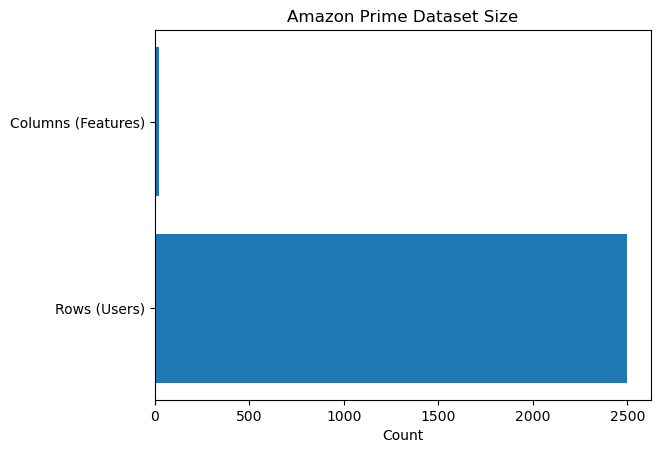

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

rows, cols = df.shape

labels = ["Rows (Users)", "Columns (Features)"]
values = [rows, cols]

plt.figure()

plt.barh(labels, values)

plt.title("Amazon Prime Dataset Size")
plt.xlabel("Count")

plt.show()

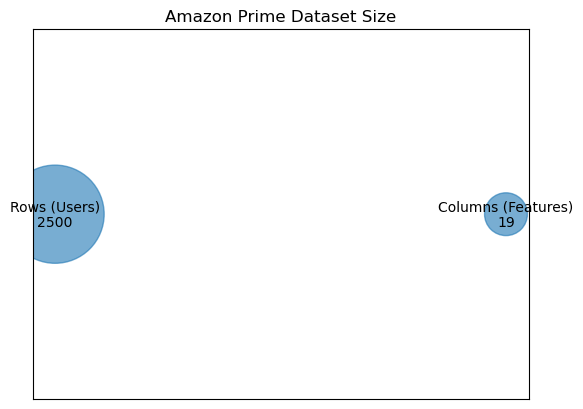

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# load dataset
path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

rows, cols = df.shape

labels = ["Rows (Users)", "Columns (Features)"]
values = [rows, cols]

# bubble positions
x = [1, 2]
y = [1, 1]

plt.figure()

plt.scatter(x, y, s=[rows*2, cols*50], alpha=0.6)

for i, label in enumerate(labels):
    plt.text(x[i], y[i], f"{label}\n{values[i]}", ha='center', va='center')

plt.title("Amazon Prime Dataset Size")
plt.xticks([])
plt.yticks([])

plt.show()

In [ ]:
import pandas as pd
import plotly.express as px

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

rows, cols = df.shape

data = pd.DataFrame({
    "Metric": ["Rows (Users)", "Columns (Features)"],
    "Count": [rows, cols]
})

fig = px.scatter(
    data,
    x=["Dataset","Dataset"],
    y="Metric",
    size="Count",
    color="Metric",
    text="Count",
    size_max=200,
    title="Amazon Prime Dataset Size Overview",
    color_discrete_sequence=["#00C853","#FF6D00"]
)

fig.update_traces(textposition='middle center')

fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

# dataset shape
rows = 2500
cols = 19

data = pd.DataFrame({
    "Metric": ["Rows (Users)", "Columns (Features)"],
    "Count": [rows, cols],
    "Position": ["Rows", "Columns"]
})

fig = px.scatter(
    data,
    x="Position",
    y="Count",
    size="Count",
    color="Metric",
    text="Count",
    size_max=200,
    title="Amazon Prime Dataset Size Overview",
    color_discrete_sequence=["#00C853","#FF6D00"]
)

fig.update_traces(textposition='middle center')

fig.update_layout(
    yaxis_title="Count",
    xaxis_title="Dataset Metrics"
)

fig.show()

In [84]:
import pandas as pd
import plotly.express as px

rows = 2500
cols = 19

data = pd.DataFrame({
    "Metric": ["Rows (Users)", "Columns (Features)"],
    "Count": [rows, cols],
    "Size": [20, 20]   # manual bubble sizes
})

fig = px.scatter(
    data,
    x=["Rows","Columns"],
    y="Count",
    size="Size",
    color="Metric",
    text="Count",
    size_max=120,
    title="Amazon Prime Dataset Size Overview",
    color_discrete_sequence=["#00C853","#FF6D00"]
)

fig.update_traces(textposition="middle center")

fig.update_layout(
    yaxis_title="Count",
    xaxis_title="Dataset Metrics"
)

fig.show()

In [85]:
import pandas as pd
import plotly.express as px

rows = 2500
cols = 19

data = pd.DataFrame({
    "Metric": ["Rows (Users)", "Columns (Features)"],
    "Count": [rows, cols]
})

fig = px.scatter(
    data,
    x=["Rows","Columns"],
    y="Count",
    size="Count",
    color="Metric",
    text="Count",
    size_max=80,
    color_discrete_sequence=["#2ecc71","#f39c12"]
)

# control bubble scaling
fig.update_traces(marker=dict(sizemode='area',
                              sizeref=2.*max(data["Count"])/(80**2),
                              line=dict(width=2,color="black")))

fig.update_layout(
    title="Amazon Prime Dataset Size Overview",
    yaxis_title="Count",
    xaxis_title="Dataset Metrics"
)

fig.show()

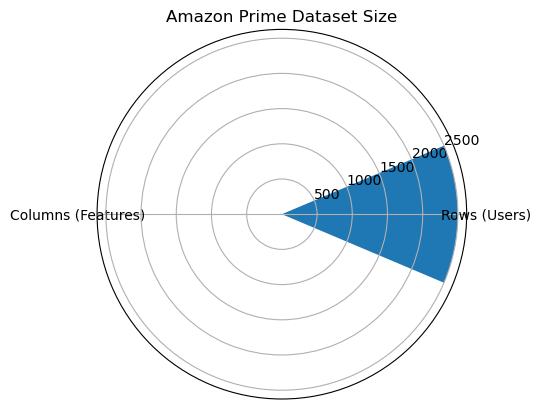

In [86]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Rows (Users)', 'Columns (Features)']
values = [2500, 19]

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)

fig = plt.figure()
ax = plt.subplot(111, polar=True)

ax.bar(angles, values)

ax.set_xticks(angles)
ax.set_xticklabels(labels)

plt.title("Amazon Prime Dataset Size")

plt.show()

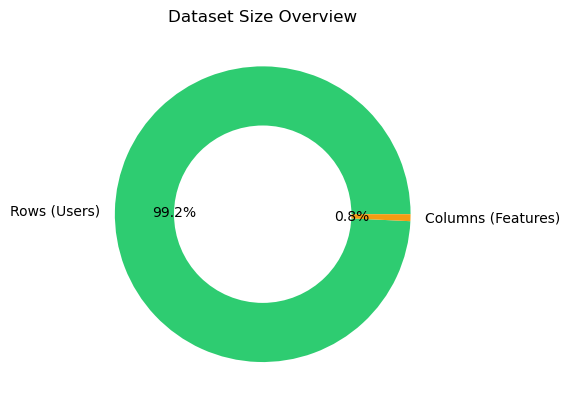

In [87]:
import matplotlib.pyplot as plt

labels = ["Rows (Users)", "Columns (Features)"]
values = [2500, 19]
colors = ["#2ecc71", "#f39c12"]

plt.figure()

plt.pie(values, labels=labels, colors=colors, autopct='%1.1f%%')

centre_circle = plt.Circle((0,0),0.60,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Dataset Size Overview")

plt.show()

In [88]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Indicator(
    mode = "gauge+number",
    value = 2500,
    title = {'text': "Total Users"},
    gauge = {'axis': {'range': [0, 3000]}}
))

fig.show()

In [89]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

rows = 2500
cols = 19

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type":"indicator"},{"type":"indicator"}]],
    subplot_titles=("Total Users", "Total Features")
)

# Users gauge
fig.add_trace(
    go.Indicator(
        mode="gauge+number",
        value=rows,
        title={'text':"Users"},
        gauge={'axis': {'range':[0,3000]},
               'bar':{'color':'green'}}
    ),
    row=1, col=1
)

# Features gauge
fig.add_trace(
    go.Indicator(
        mode="gauge+number",
        value=cols,
        title={'text':"Features"},
        gauge={'axis': {'range':[0,30]},
               'bar':{'color':'orange'}}
    ),
    row=1, col=2
)

fig.update_layout(title="Amazon Prime Dataset Size Overview")

fig.show()

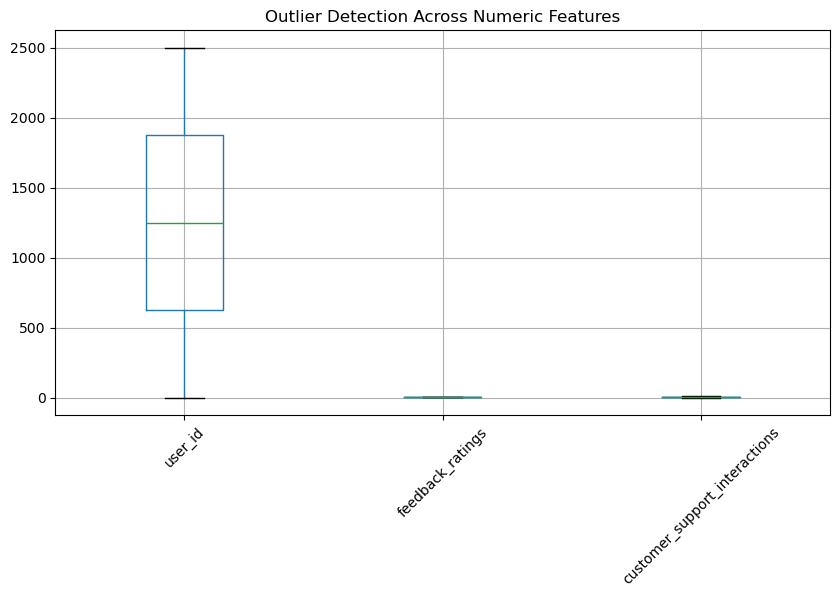

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(10,5))

df[numeric_cols].boxplot()

plt.title("Outlier Detection Across Numeric Features")
plt.xticks(rotation=45)

plt.show()

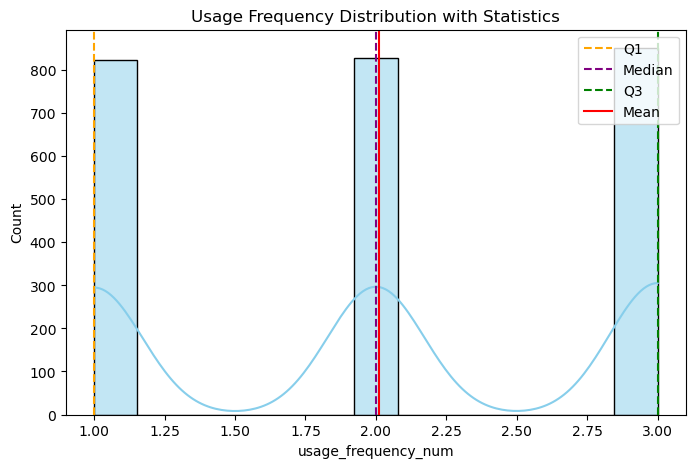

Mean: 2.0116
Median: 2.0
Mode: 3
Q1: 1.0
Q2: 2.0
Q3: 3.0


In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

# convert categorical frequency to numeric
mapping = {
    "Occasional":1,
    "Regular":2,
    "Frequent":3
}

df["usage_frequency_num"] = df["usage_frequency"].map(mapping)

data = df["usage_frequency_num"].dropna()

# statistics
mean_val = data.mean()
median_val = data.median()
mode_val = data.mode()[0]

q1 = data.quantile(0.25)
q2 = data.quantile(0.50)
q3 = data.quantile(0.75)

plt.figure(figsize=(8,5))

sns.histplot(data, kde=True, color="skyblue")

plt.axvline(q1,color="orange",linestyle="--",label="Q1")
plt.axvline(q2,color="purple",linestyle="--",label="Median")
plt.axvline(q3,color="green",linestyle="--",label="Q3")

plt.axvline(mean_val,color="red",label="Mean")

plt.legend()
plt.title("Usage Frequency Distribution with Statistics")

plt.show()

print("Mean:",mean_val)
print("Median:",median_val)
print("Mode:",mode_val)
print("Q1:",q1)
print("Q2:",q2)
print("Q3:",q3)

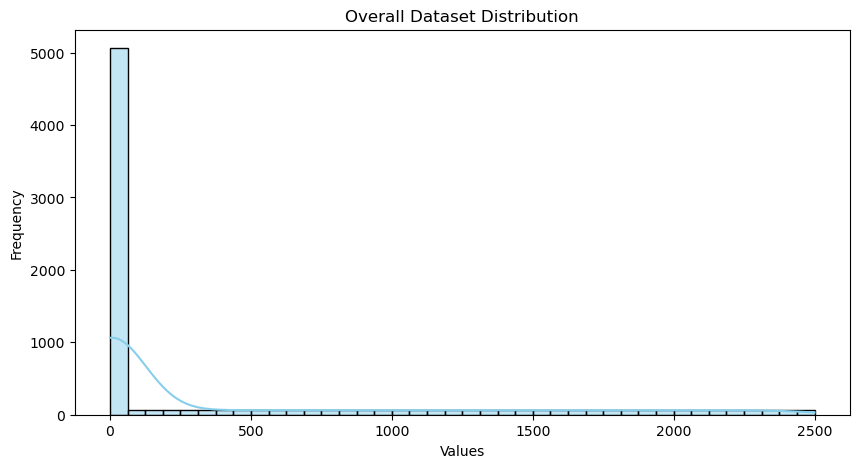

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

# select numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(10,5))

sns.histplot(df[numeric_cols].stack(), kde=True, color="skyblue")

plt.title("Overall Dataset Distribution")

plt.xlabel("Values")
plt.ylabel("Frequency")

plt.show()

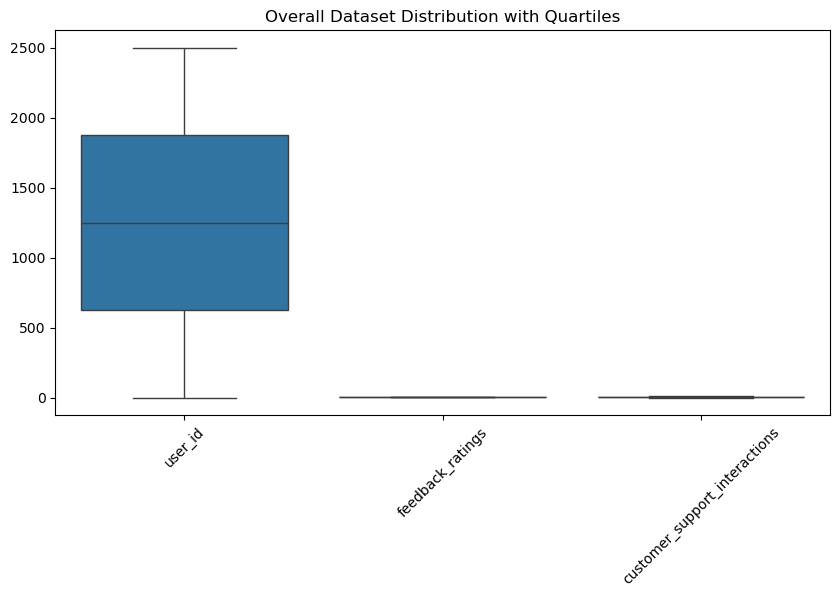

In [94]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df[numeric_cols])

plt.title("Overall Dataset Distribution with Quartiles")

plt.xticks(rotation=45)

plt.show()

In [95]:
stats = df.describe()

print(stats)

          user_id  feedback_ratings  customer_support_interactions
count  2500.00000       2500.000000                    2500.000000
mean   1250.50000          4.004760                       4.951600
std     721.83216          0.580769                       3.191572
min       1.00000          3.000000                       0.000000
25%     625.75000          3.500000                       2.000000
50%    1250.50000          4.000000                       5.000000
75%    1875.25000          4.500000                       8.000000
max    2500.00000          5.000000                      10.000000


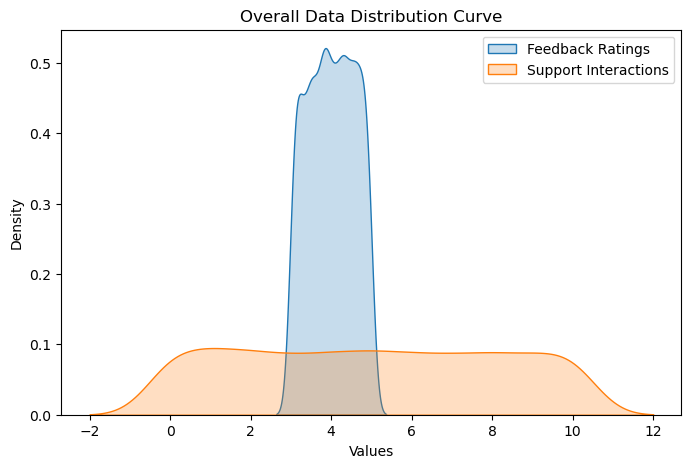

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

plt.figure(figsize=(8,5))

sns.kdeplot(df["feedback_ratings"], label="Feedback Ratings", fill=True)
sns.kdeplot(df["customer_support_interactions"], label="Support Interactions", fill=True)

plt.title("Overall Data Distribution Curve")
plt.xlabel("Values")
plt.ylabel("Density")

plt.legend()

plt.show()

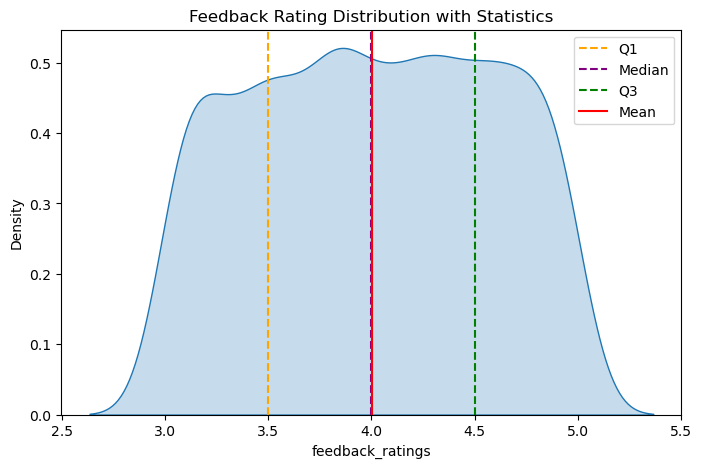

In [97]:
feature = df["feedback_ratings"]

q1 = feature.quantile(0.25)
q2 = feature.quantile(0.50)
q3 = feature.quantile(0.75)

mean_val = feature.mean()

plt.figure(figsize=(8,5))

sns.kdeplot(feature, fill=True)

plt.axvline(q1,color="orange",linestyle="--",label="Q1")
plt.axvline(q2,color="purple",linestyle="--",label="Median")
plt.axvline(q3,color="green",linestyle="--",label="Q3")
plt.axvline(mean_val,color="red",label="Mean")

plt.legend()

plt.title("Feedback Rating Distribution with Statistics")

plt.show()

In [98]:
import pandas as pd

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

mapping = {
    "Occasional":1,
    "Regular":2,
    "Frequent":3
}

df["usage_num"] = df["usage_frequency"].map(mapping)

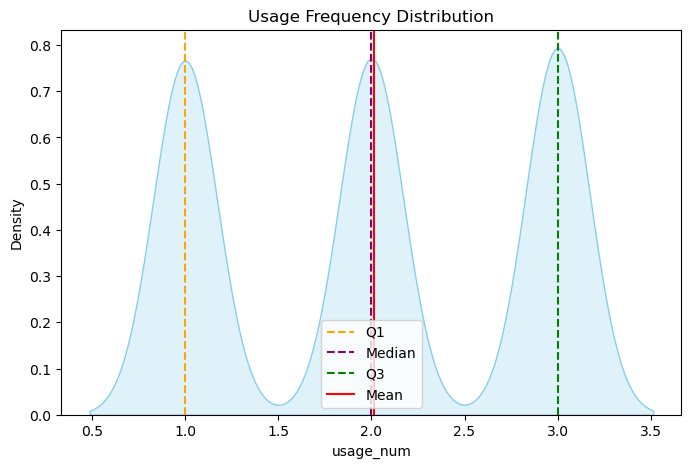

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

data = df["usage_num"]

mean_val = data.mean()
median_val = data.median()

q1 = data.quantile(0.25)
q2 = data.quantile(0.50)
q3 = data.quantile(0.75)

plt.figure(figsize=(8,5))

sns.kdeplot(data, fill=True, color="skyblue")

plt.axvline(q1,color="orange",linestyle="--",label="Q1")
plt.axvline(q2,color="purple",linestyle="--",label="Median")
plt.axvline(q3,color="green",linestyle="--",label="Q3")

plt.axvline(mean_val,color="red",label="Mean")

plt.title("Usage Frequency Distribution")

plt.legend()

plt.show()

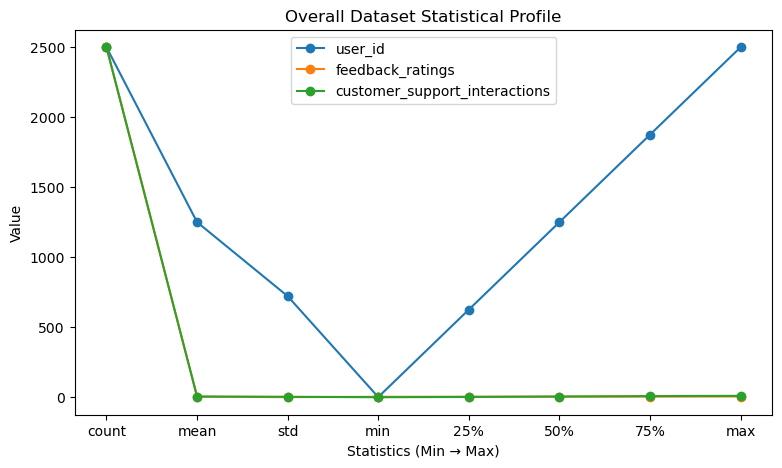

In [100]:
import pandas as pd
import matplotlib.pyplot as plt

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

# get statistics
stats = df.describe()

plt.figure(figsize=(9,5))

for col in stats.columns:
    plt.plot(stats.index, stats[col], marker='o', label=col)

plt.title("Overall Dataset Statistical Profile")
plt.xlabel("Statistics (Min → Max)")
plt.ylabel("Value")
plt.legend()

plt.show()

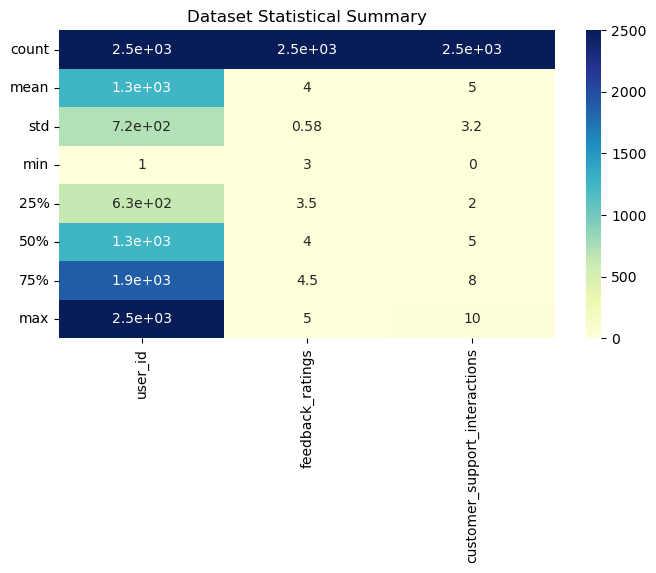

In [101]:
import seaborn as sns

plt.figure(figsize=(8,4))

sns.heatmap(stats, annot=True, cmap="YlGnBu")

plt.title("Dataset Statistical Summary")

plt.show()

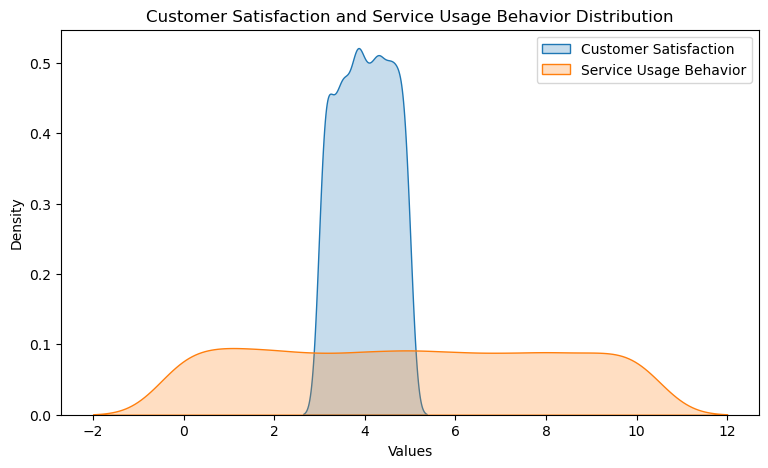

In [102]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

plt.figure(figsize=(9,5))

sns.kdeplot(df["feedback_ratings"], fill=True, label="Customer Satisfaction")
sns.kdeplot(df["customer_support_interactions"], fill=True, label="Service Usage Behavior")

plt.title("Customer Satisfaction and Service Usage Behavior Distribution")
plt.xlabel("Values")
plt.ylabel("Density")

plt.legend()

plt.show()

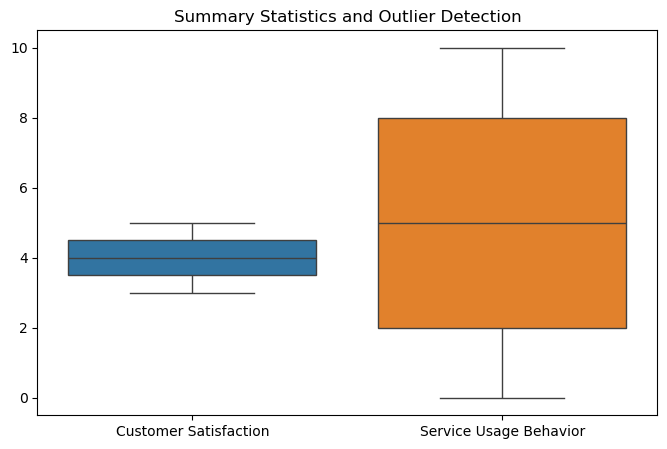

In [103]:
plt.figure(figsize=(8,5))

data = df[["feedback_ratings","customer_support_interactions"]]
data.columns = ["Customer Satisfaction","Service Usage Behavior"]

sns.boxplot(data=data)

plt.title("Summary Statistics and Outlier Detection")

plt.show()

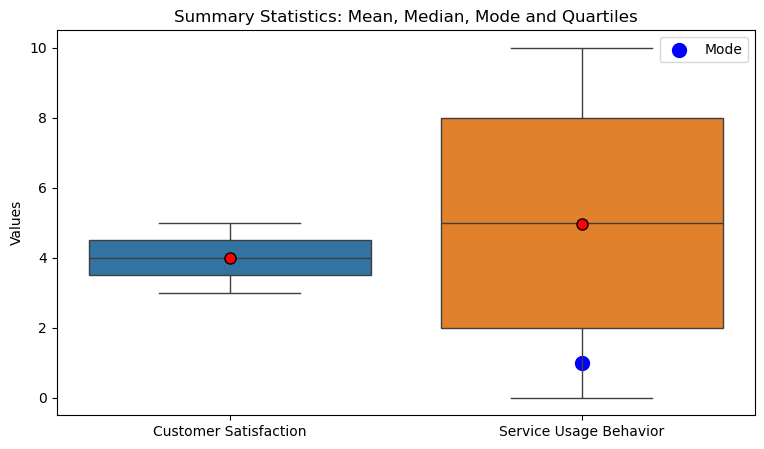

In [104]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

data = df[["feedback_ratings","customer_support_interactions"]]
data.columns = ["Customer Satisfaction","Service Usage Behavior"]

plt.figure(figsize=(9,5))

sns.boxplot(data=data, showmeans=True,
            meanprops={"marker":"o","markerfacecolor":"red","markeredgecolor":"black","markersize":"8"})

# plot mode
for i,col in enumerate(data.columns):
    mode_val = data[col].mode()[0]
    plt.scatter(i, mode_val, color="blue", s=100, label="Mode" if i==0 else "")

plt.title("Summary Statistics: Mean, Median, Mode and Quartiles")

plt.ylabel("Values")

plt.legend()

plt.show()

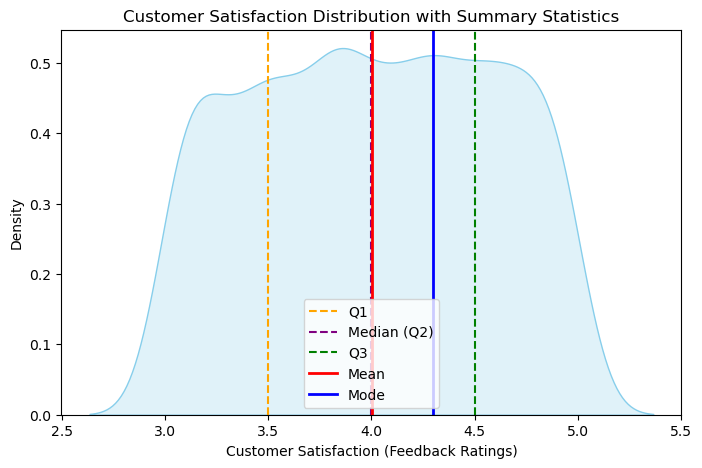

In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

data = df["feedback_ratings"]

# summary statistics
mean_val = data.mean()
median_val = data.median()
mode_val = data.mode()[0]

q1 = data.quantile(0.25)
q2 = data.quantile(0.50)
q3 = data.quantile(0.75)

plt.figure(figsize=(8,5))

# distribution curve
sns.kdeplot(data, fill=True, color="skyblue")

# quartile lines
plt.axvline(q1, color="orange", linestyle="--", label="Q1")
plt.axvline(q2, color="purple", linestyle="--", label="Median (Q2)")
plt.axvline(q3, color="green", linestyle="--", label="Q3")

# mean and mode
plt.axvline(mean_val, color="red", linewidth=2, label="Mean")
plt.axvline(mode_val, color="blue", linewidth=2, label="Mode")

plt.title("Customer Satisfaction Distribution with Summary Statistics")
plt.xlabel("Customer Satisfaction (Feedback Ratings)")
plt.ylabel("Density")

plt.legend()

plt.show()

In [106]:
import pandas as pd

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

cols = ["feedback_ratings","customer_support_interactions"]

summary_stats = pd.DataFrame({
    "Mean": df[cols].mean(),
    "Median (Q2)": df[cols].median(),
    "Mode": df[cols].mode().iloc[0],
    "Q1 (25%)": df[cols].quantile(0.25),
    "Q3 (75%)": df[cols].quantile(0.75),
    "Min": df[cols].min(),
    "Max": df[cols].max(),
    "Std Dev": df[cols].std()
})

summary_stats.index = ["Customer Satisfaction","Service Usage Behavior"]

print(summary_stats)

                           Mean  Median (Q2)  Mode  Q1 (25%)  Q3 (75%)  Min  \
Customer Satisfaction   4.00476          4.0   4.3       3.5       4.5  3.0   
Service Usage Behavior  4.95160          5.0   1.0       2.0       8.0  0.0   

                         Max   Std Dev  
Customer Satisfaction    5.0  0.580769  
Service Usage Behavior  10.0  3.191572  


In [107]:
import pandas as pd

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

cols = ["feedback_ratings","customer_support_interactions"]

summary_stats = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median (Q2)",
        "Mode",
        "Q1 (25%)",
        "Q3 (75%)",
        "Minimum",
        "Maximum",
        "Standard Deviation"
    ],
    
    "Customer Satisfaction": [
        df["feedback_ratings"].mean(),
        df["feedback_ratings"].median(),
        df["feedback_ratings"].mode()[0],
        df["feedback_ratings"].quantile(0.25),
        df["feedback_ratings"].quantile(0.75),
        df["feedback_ratings"].min(),
        df["feedback_ratings"].max(),
        df["feedback_ratings"].std()
    ],
    
    "Service Usage Behavior": [
        df["customer_support_interactions"].mean(),
        df["customer_support_interactions"].median(),
        df["customer_support_interactions"].mode()[0],
        df["customer_support_interactions"].quantile(0.25),
        df["customer_support_interactions"].quantile(0.75),
        df["customer_support_interactions"].min(),
        df["customer_support_interactions"].max(),
        df["customer_support_interactions"].std()
    ]
})

print(summary_stats)

            Statistic  Customer Satisfaction  Service Usage Behavior
0                Mean               4.004760                4.951600
1         Median (Q2)               4.000000                5.000000
2                Mode               4.300000                1.000000
3            Q1 (25%)               3.500000                2.000000
4            Q3 (75%)               4.500000                8.000000
5             Minimum               3.000000                0.000000
6             Maximum               5.000000               10.000000
7  Standard Deviation               0.580769                3.191572


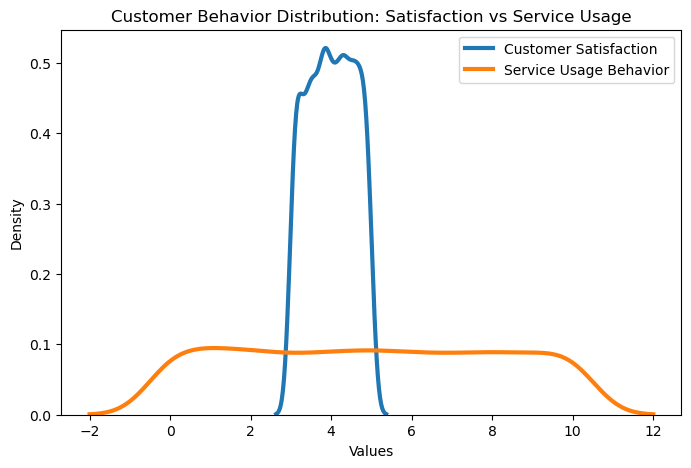

In [108]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

plt.figure(figsize=(8,5))

sns.kdeplot(df["feedback_ratings"], 
            label="Customer Satisfaction", 
            linewidth=3)

sns.kdeplot(df["customer_support_interactions"], 
            label="Service Usage Behavior", 
            linewidth=3)

plt.title("Customer Behavior Distribution: Satisfaction vs Service Usage")

plt.xlabel("Values")
plt.ylabel("Density")

plt.legend()

plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[["feedback_ratings","customer_support_interactions"]] = scaler.fit_transform(
    df[["feedback_ratings","customer_support_interactions"]]
)

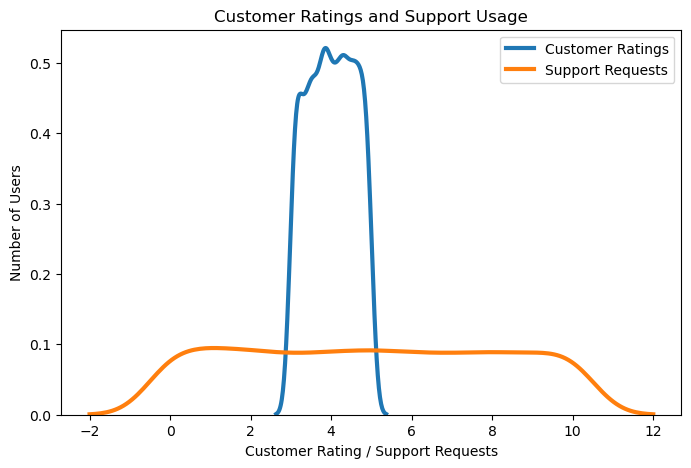

In [109]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# load dataset
path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

plt.figure(figsize=(8,5))

# line distribution curves
sns.kdeplot(df["feedback_ratings"],
            label="Customer Ratings",
            linewidth=3)

sns.kdeplot(df["customer_support_interactions"],
            label="Support Requests",
            linewidth=3)

# simple titles
plt.title("Customer Ratings and Support Usage")

plt.xlabel("Customer Rating / Support Requests")

plt.ylabel("Number of Users")

plt.legend()

plt.show()

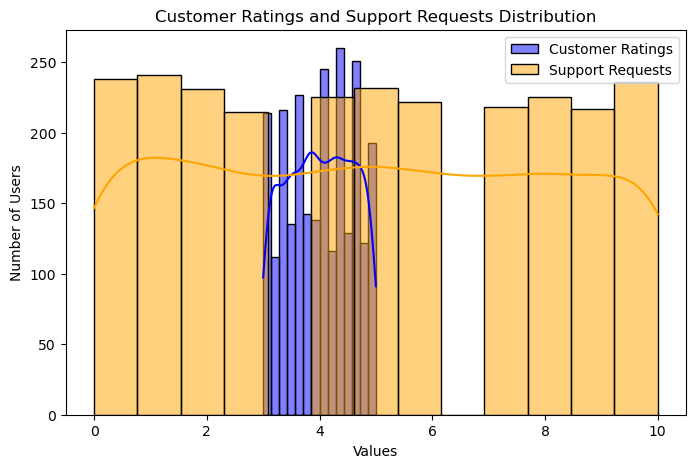

In [110]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path = r"C:\Users\ranar\OneDrive\Documents\Mcmaster University\Data_Mining\Project 01\amazon_prime_data.csv"
df = pd.read_csv(path)

plt.figure(figsize=(8,5))

sns.histplot(df["feedback_ratings"], kde=True, color="blue", label="Customer Ratings")
sns.histplot(df["customer_support_interactions"], kde=True, color="orange", label="Support Requests")

plt.title("Customer Ratings and Support Requests Distribution")

plt.xlabel("Values")
plt.ylabel("Number of Users")

plt.legend()

plt.show()

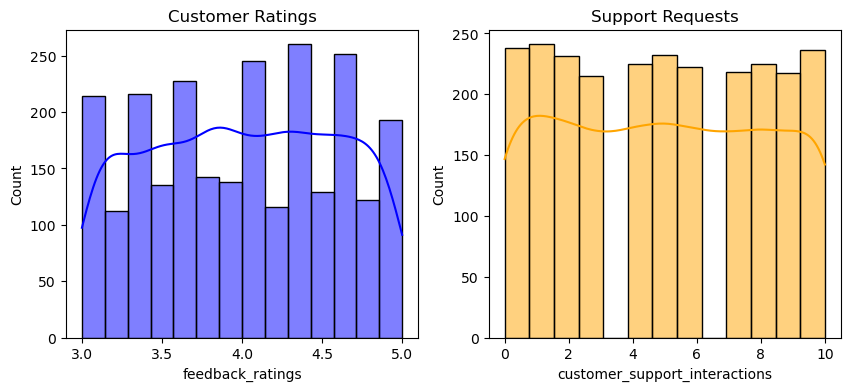

In [111]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

sns.histplot(df["feedback_ratings"], kde=True, ax=ax[0], color="blue")
ax[0].set_title("Customer Ratings")

sns.histplot(df["customer_support_interactions"], kde=True, ax=ax[1], color="orange")
ax[1].set_title("Support Requests")

plt.show()

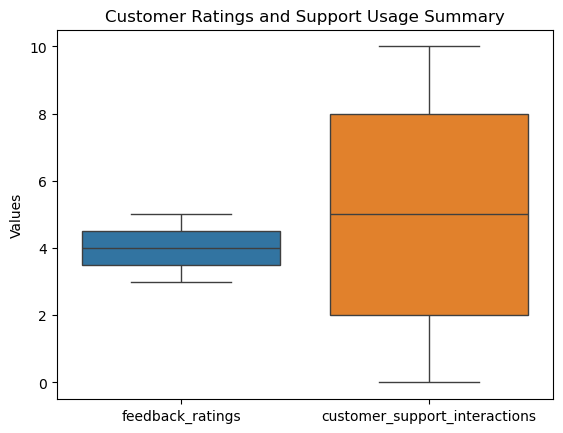

In [113]:
sns.boxplot(data=df[["feedback_ratings","customer_support_interactions"]])

plt.title("Customer Ratings and Support Usage Summary")

plt.ylabel("Values")

plt.show()